In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [173]:
df_frb = pd.read_csv("chimefrbcat2.csv")


# set seeds as 42
np.random.seed(52)
scipy_seed = 52

In [174]:
df_frb.columns

Index(['tns_name', 'previous_name', 'repeater_name', 'event_id', 'sub_num',
       'ra', 'ra_err', 'dec', 'dec_err', 'ra_dec_notes', 'gl', 'gb', 'exp_up',
       'exp_up_err', 'exp_low', 'exp_low_err', 'exp_notes', 'bonsai_snr',
       'bonsai_dm', 'low_ft_68', 'up_ft_68', 'low_ft_95', 'up_ft_95',
       'snr_fitb', 'dm_fitb', 'dm_fitb_err', 'dm_exc_ne2001', 'dm_exc_ymw16',
       'bc_width', 'scat_time', 'scat_time_err', 'flux', 'flux_err', 'fluence',
       'fluence_err', 'fluence_notes', 'fluence_win_extended', 'mjd_400',
       'mjd_400_err', 'mjd_inf', 'mjd_inf_err', 'width_fitb', 'width_fitb_err',
       'sp_idx', 'sp_idx_err', 'sp_run', 'sp_run_err', 'high_freq', 'low_freq',
       'peak_freq', 'chi_sq', 'dof', 'flag_frac', 'notes_fitb',
       'intrachan_flag', 'excluded_flag', 'sidelobe_flag',
       'citizen_science_flag', 'catalog1_flag', 'catalog1_param_flag'],
      dtype='str')

In [ ]:
df_frb["repeater_name"] = df_frb["repeater_name"].fillna("None").str.strip()
df_frb['repeater'] = df_frb['repeater_name'].apply(lambda x: 1 if x != "None" else 0)
df_frb['repeater'].value_counts()

repeater
0    3763
1    1282
Name: count, dtype: int64

In [176]:
important_params = ["width_fitb", "sp_idx", "sp_run", "scat_time"]

df_rep = df_frb[df_frb['repeater'] == 1][important_params].dropna()
df_nonrep = df_frb[df_frb['repeater'] == 0][important_params].dropna()

df_nonrep.describe()

,width_fitb,sp_idx,sp_run,scat_time
count,3.686000e+03,3686.000000,3686.000000,3686.000000
mean,1.151166e-03,24.761027,-52.841188,0.013720
std,1.861810e-03,118.668961,154.970659,0.052234
min,4.343407e-08,-19.485484,-4310.779765,0.000000
25%,3.207640e-04,0.929761,-65.418690,0.000000
50%,6.004095e-04,5.795647,-14.288282,0.000000
75%,1.204484e-03,20.145426,-5.657640,0.008374
max,2.733518e-02,3490.607089,23.929616,1.522080


In [ ]:
# make KDE for the four parameters for repeaters and non-repeaters
kde_rep = gaussian_kde(df_rep.values.T)
kde_nonrep = gaussian_kde(df_nonrep.values.T)

In [178]:
from fitburst.analysis.model import SpectrumModeler

bounds = {
    "width_fitb": (df_frb["width_fitb"].quantile(0.05), df_frb["width_fitb"].quantile(0.95)),
    "sp_idx": (df_frb["sp_idx"].quantile(0.05), df_frb["sp_idx"].quantile(0.95)),
    "sp_run": (df_frb["sp_run"].quantile(0.05), df_frb["sp_run"].quantile(0.95)),
    "scat_time": (df_frb["scat_time"].quantile(0.05), df_frb["scat_time"].quantile(0.95))
}

rng = np.random.default_rng(52)


def sample_kde(kde, bounds, n):
    samples = []
    while len(samples) < n:
        sample = kde.resample(1, seed=rng).flatten()
        if all(bounds[param][0] <= sample[i] <= bounds[param][1] for i, param in enumerate(bounds)):
            samples.append(sample)
    return np.array(samples)

In [179]:
n_freq = 256
n_timesteps = 128
dt = 0.0009830400085775182 * 1000 #ms

freqs = np.linspace(400, 800, n_freq)
times_ms = np.arange(n_timesteps) * dt
times_s = times_ms / 1000.0


sample_frb = sample_kde(kde_nonrep, bounds, 1)[0]
width_fitb, sp_idx, sp_run, scat_time = sample_frb

model_obj = SpectrumModeler(freqs, times_s)
center_time = times_s[len(times_s) // 2]

print(f"Sampled parameters: width_fitb={width_fitb}, sp_idx={sp_idx}, sp_run={sp_run}, scat_time={scat_time}")


# taken from example in fitburst repo
params = {'amplitude': [-0.4812764314320905],
 'arrival_time': [center_time],
 'burst_width': [0.00027258462551453457],
 'dm': [0.0],
 'dm_index': [-2.0],
 'ref_freq': [400.1953125],
 'scattering_index': [-4.0],
 'scattering_timescale': [0.0],
 'spectral_index': [2.8705490561459213],
 'spectral_running': [-15.86167822219646]}

model_obj.update_parameters(params)

Sampled parameters: width_fitb=0.004845528810644565, sp_idx=29.003578204282654, sp_run=-50.8358751648572, scat_time=0.000900970851352961


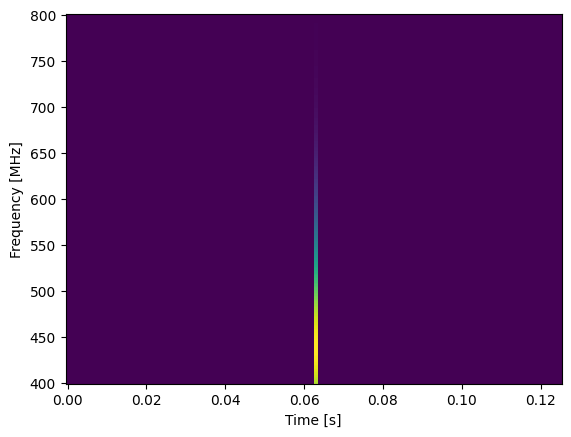

In [180]:
model = model_obj.compute_model()

# now plot.
plt.pcolormesh(times_s, freqs, model)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [MHz]")
plt.show()

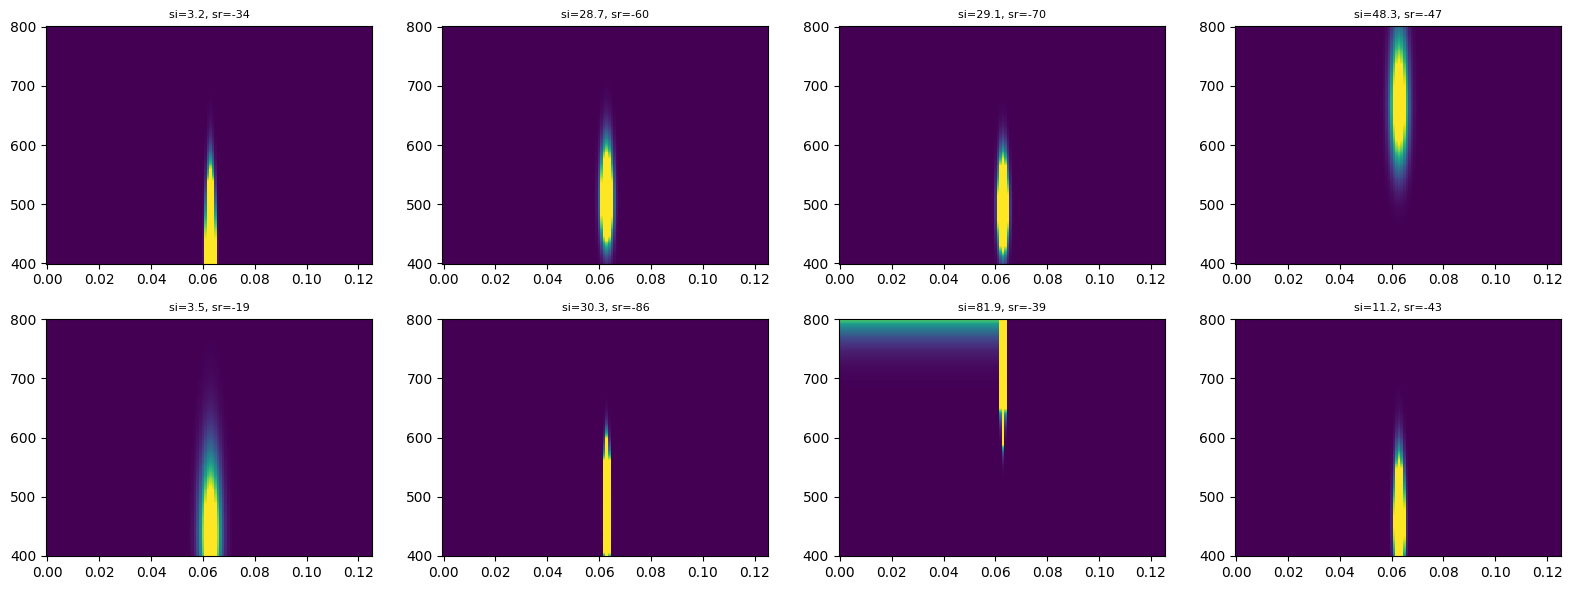

In [181]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax in axes.flat:
    s = sample_kde(kde_nonrep, bounds, 1)[0]
    scatter_index = rng.uniform(-4.4, -3.5)
    w, si, sr, st = s
    model_obj.update_parameters({
        "amplitude": [1.0], "arrival_time": [center_time],
        "burst_width": [w], "dm": [0], "dm_index": [-2.0],
        "ref_freq": [400.192], "scattering_timescale": [st/1000],
        "scattering_index": [scatter_index], "spectral_index": [si], "spectral_running": [sr],
    })
    m = model_obj.compute_model()
    vmin, vmax = np.nanpercentile(m, [1, 99])
    ax.pcolormesh(times_s, freqs, m, vmin=vmin, vmax=vmax)
    ax.set_title(f"si={si:.1f}, sr={sr:.0f}", fontsize=8)
plt.tight_layout()
plt.show()